In [1]:
# importing the packages:
from dataclasses import dataclass
import os
import numpy as np
import pandas as pd
from typing import List, Tuple, Dict, Optional
from tqdm.notebook import tqdm

# survival
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored
from sksurv.linear_model import CoxnetSurvivalAnalysis

# modeling utils
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer

# univariate cox (optional)
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
from statsmodels.stats.multitest import multipletests
from lifelines.statistics import logrank_test
from lifelines.statistics import multivariate_logrank_test
from statsmodels.stats.contingency_tables import Table

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.table import Table


import math
import sys
import scipy.stats
from scipy.stats import norm
from scipy.stats import zscore
from scipy.stats import fisher_exact
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings("ignore")

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # embed TrueType fonts, keep text editable
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans'] 

*Reading the dataframe:*

In [2]:
cutoff = 2000

In [3]:
print('reading the main dataframe:')
d35_input_full = pd.read_excel(f'/g/scb2/zaugg/stapran/24_09_FACS_Project_Iter2/DATA/patient_data_excels/d35/FinalPopulationPercentages_ClinicalInfo_3000threshold_2026_06_28.xlsx')
d35_input_full_copy = d35_input_full[(d35_input_full['OC_d35_PassCrit_FCAnalysis'] == 'Yes') | (d35_input_full['VC_d35_PassCrit_FCAnalysis'] == 'Yes')]

PERCENT_FEATURES = [c for c in d35_input_full_copy.columns if ' of ' in c]
myeloid_endings = [' of DC/HLA-DRpos_APC',' of Monocytes',' of Myeloid']
myeloid_endings_and_CD45pos = [' of DC/HLA-DRpos_APC',' of Monocytes',' of Myeloid', ' of CD45pos']
myeloid_child = set(element.split(' of ')[0] for element in PERCENT_FEATURES if element.endswith(tuple(myeloid_endings)))
myeloid_params_exclude = [element for element in PERCENT_FEATURES if element.startswith(tuple(myeloid_child)) and element.endswith(tuple(myeloid_endings_and_CD45pos))]
PERCENT_FEATURES = list(set(PERCENT_FEATURES) - set(myeloid_params_exclude))

PERCENT_FEATURES_renamer = {}
to_rename = [element for element in PERCENT_FEATURES if 'LowLevel' in element]
for element in to_rename:
    PERCENT_FEATURES_renamer[element] = element.replace('LowLevel ', 'High Resolution ')
d35_input_full_copy = d35_input_full_copy.rename(columns = PERCENT_FEATURES_renamer)
PERCENT_FEATURES = [element.replace('LowLevel ', 'High Resolution ') for element in PERCENT_FEATURES]

RATIO_FEATURES   = [c for c in d35_input_full_copy.columns if '-to-' in c]
# d35_input_full_copy[PERCENT_FEATURES] = np.arcsin(np.sqrt(np.clip(d35_input_full_copy[PERCENT_FEATURES] / 100, 0, 1)))

# d35_input_full_copy['Sex_Mismatch'] = np.where(d35_input_full_copy['Sex_Recipient'] == d35_input_full_copy['Sex_Donor'], 0, 1)
# d35_input_full_copy['Sex_Recipient'] = np.where(d35_input_full_copy['Sex_Recipient'] == 'Male', 0, 1) # Male = 0, Female = 1
# d35_input_full_copy['CMV_Status_Mismatch'] = np.where(d35_input_full_copy['CMV_Status_Recipient'] == d35_input_full_copy['CMV_Status_Donor'], 0, 1)
# d35_input_full_copy['CMV_Status_Recipient'] = np.where(d35_input_full_copy['CMV_Status_Recipient'] == 'neg', 0, 1) # neg = 0, pos = 1
# d35_input_full_copy['MHC_Mismatch_between_Donor&Recipient'] = np.where(d35_input_full_copy['MHC_Mismatch_between_Donor&Recipient'] == 'nein', 0, 1) # no = 0, yes = 1

OUTCOME_COLS = {
    "RFS": {"time": 'Time_to_Relapse_from_TPL', "event": 'Relapse_Present_1_NotObserved_0'},
    "OS":  {"time": 'Time_to_Death_from_TPL',  "event": 'Death_Present_1_NotObserved_0'},
    "aGVHD": {"time": "Time_to_aGVHD", "event": "aGVHD_grading_by_Katja"},
    "cGVHD": {"time": "Time_to_cGVHD", "event": "cGVHD_grading_by_Katja"},
}

d35_input_full_copy[OUTCOME_COLS['RFS']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['RFS']['time']] >= cutoff, 0, d35_input_full_copy[OUTCOME_COLS['RFS']['event']])
d35_input_full_copy[OUTCOME_COLS['RFS']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['RFS']['time']] >= cutoff, cutoff, d35_input_full_copy[OUTCOME_COLS['RFS']['time']])

d35_input_full_copy[OUTCOME_COLS['OS']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['OS']['time']] >= cutoff, 0, d35_input_full_copy[OUTCOME_COLS['OS']['event']])
d35_input_full_copy[OUTCOME_COLS['OS']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['OS']['time']] >= cutoff, cutoff, d35_input_full_copy[OUTCOME_COLS['OS']['time']])

d35_input_full_copy[OUTCOME_COLS['aGVHD']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] >= cutoff, 0, d35_input_full_copy[OUTCOME_COLS['aGVHD']['event']])
d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] >= cutoff, cutoff, d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']])

d35_input_full_copy[OUTCOME_COLS['cGVHD']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] >= cutoff, 0, d35_input_full_copy[OUTCOME_COLS['cGVHD']['event']])
d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] >= cutoff, cutoff, d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']])


d35_input_full_copy['Relapse_Present_1_NotObserved_0'] = d35_input_full_copy['Relapse_Present_1_NotObserved_0'].astype("Int64")
d35_input_full_copy['aGVHD_grading_by_Katja'] = d35_input_full_copy['aGVHD_grading_by_Katja'].astype("Int64")
d35_input_full_copy['cGVHD_grading_by_Katja'] = d35_input_full_copy['cGVHD_grading_by_Katja'].astype("Int64")
d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'] = round(d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'], 0)
d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'] = d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'].astype("Int64")
d35_input_full_copy['MAX_FOLLOW_UP'] = d35_input_full_copy[['Time_to_aGVHD', 'Time_to_cGVHD',
                                                            'Time_to_Relapse_from_TPL','Time_to_Death_from_TPL']].max(axis = 1)


d35_input_full_copy['Time_to_Death_from_TPL'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['Time_to_Relapse_from_TPL'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['Time_to_aGVHD'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
# only 65 patients (40 in VC and 25 in OC)
d35_input_full_copy['Time_to_cGVHD'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['MAX_FOLLOW_UP'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']

reading the main dataframe:


<br></br>
<br></br>
<br></br>
*Setting up the score:*

In [5]:
df_multivariate = d35_input_full_copy.copy()
age_cutoff = 60
df_multivariate[f'Age(>{age_cutoff})'] = np.where(df_multivariate['Age'] > age_cutoff, 1, 0)
df_multivariate['MHC_Mismatch_between_Donor&Recipient'] = np.where(df_multivariate['MHC_Mismatch_between_Donor&Recipient'] == 'nein', 'Match', 'Mismatch')
df_multivariate['MHC_Mismatch_Numeric'] = np.where(df_multivariate['HLA_Category_refined'] != '10/10', 'Mismatch', '10/10')
df_multivariate['ELN_Score(3)'] = np.where(df_multivariate['ELN_Score'] == 3, 1, 0)
d35_input_full_copy['Sex_Recipient(M=1)'] = np.where(d35_input_full_copy['Sex_Recipient'] == 'Male', 1, 0) # Male = 0, Female = 1

df_multivariate['Disease_Score(2)'] = np.where(df_multivariate['Disease_Score'] == 2, 1, 0)
df_multivariate['CMV_Status_Recipient(+)'] = np.where(df_multivariate['CMV_Status_Recipient'] == 'neg', "CMV R neg", "CMV R pos")
df_multivariate['CMV_Status(R/D)'] = df_multivariate['CMV_Status_Recipient'] + '_' + df_multivariate['CMV_Status_Donor']
df_multivariate['CMV_Status(R/D)'] = df_multivariate['CMV_Status(R/D)'].replace({
    'pos_pos': '+/+',
    'neg_neg': 'Other',
    'pos_neg': 'Other',
    'neg_pos': 'Other',
})

In [11]:
parameters = {
    # 'High Resolution CD8 CCR7- CD45RAmid CD27+ CD57+ GPR56+ of CD45pos': 'GvL_Score',
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'GvL_Score',
    
    # 'High Resolution CD56dim NK CD45RA+ CD57+ CD8+ GPR56+ of Lymphocytes': 'GvHD_Score',
    'CD4 CCR7mid CD45RA- of T': 'GvHD_Score',
    'CD4_Naive+CD4_TCM-to-CD4_rest': 'GvHD_Score'
}

direction = {
    # 'High Resolution CD8 CCR7- CD45RAmid CD27+ CD57+ GPR56+ of CD45pos': 'protective',
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'protective',
    
    # 'High Resolution CD56dim NK CD45RA+ CD57+ CD8+ GPR56+ of Lymphocytes': 'protective',
    'CD4 CCR7mid CD45RA- of T': 'non-protective',
    'CD4_Naive+CD4_TCM-to-CD4_rest': 'non-protective'
}

def sign_intepreter(parameter):
    if direction[parameter] == 'protective':
        return [1,0]
    else:
        return [0,1]

cutoffs = {}
for parameter in list(parameters.keys()):
    cutoffs[parameter] = {
        'OC': np.median(df_multivariate[df_multivariate['Cohort'] == 'OC'][parameter]),
        'VC': np.median(df_multivariate[df_multivariate['Cohort'] == 'VC'][parameter])
    }

for parameter in cutoffs:
    df_multivariate[f'{parameter}_SCORE'] = np.where(df_multivariate['Cohort'] == 'OC',
                                                     np.where(df_multivariate[parameter] > cutoffs[parameter]['OC'], sign_intepreter(parameter)[0], sign_intepreter(parameter)[1]),
                                                     np.where(df_multivariate[parameter] > cutoffs[parameter]['VC'], sign_intepreter(parameter)[0], sign_intepreter(parameter)[1])
                                                    )
GvL_params = list({k:v for k,v in parameters.items() if v == 'GvL_Score'}.keys())
GvHD_params = list({k:v for k,v in parameters.items() if v == 'GvHD_Score'}.keys())
df_multivariate['GvL_Score'] = df_multivariate[[f'{element}_SCORE' for element in GvL_params]].sum(axis = 1)
df_multivariate['GvHD_Score'] = df_multivariate[[f'{element}_SCORE' for element in GvHD_params]].sum(axis = 1)
df_multivariate['GvLhi_GvHDlo'] = np.where((df_multivariate['GvL_Score'] == len({k:v for k,v in parameters.items() if v == 'GvL_Score'})) & 
                                         (df_multivariate['GvHD_Score'] == len({k:v for k,v in parameters.items() if v == 'GvHD_Score'})), 1, 0)

NK_param = 'High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes'
# 'High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes'
# "CD56dim NK CD57+ GPR56+ of Lymphocytes"
df_multivariate["CD56dimNK++_tertiles"] = (
    df_multivariate.groupby("Cohort")[NK_param]
      .transform(lambda x: pd.qcut(x, q=3, labels=["dimNK\nlo", "dimNK\nmid", "dimNK\nhi"]))
)

*Running the Fisher's tests and Fisher's plots:*

In [12]:
def fisher_plot_builder(clin_var_column, score_column, how_to_split, clin_vars_to_merge = None, scores_to_merge = None):
    df_multivariate_working_copy = df_multivariate.copy()
    if score_column == 'GvL_Score':
        label_for_bad = 'CD8 TEM +/+\n≤ median'
        label_for_good = 'CD8 TEM +/+\n> median'
        df_multivariate_working_copy['GvL_Score'] = np.where(df_multivariate_working_copy['GvL_Score'] == 0, label_for_bad, label_for_good)
        labels = [label_for_good, label_for_bad]
    elif score_column == 'GvHD_Score_Adapted':
        label_for_bad = f'GvHDScoreLo ({"/".join(str(element) for element in scores_to_merge)})'
        label_for_good = f'GvHDScoreHi ({"/".join(str(element) for element in [a for a in [0,1,2] if a not in scores_to_merge])})'
        df_multivariate_working_copy['GvHD_Score_Adapted'] = np.where(df_multivariate_working_copy['GvHD_Score'].isin(scores_to_merge), label_for_bad, label_for_good)
        labels = [label_for_good, label_for_bad]
    elif score_column == 'GvLhi_GvHDlo':
        label_for_bad = 'Other'
        label_for_good = 'ICC35-favorable'
        df_multivariate_working_copy['GvLhi_GvHDlo'] = np.where(df_multivariate_working_copy['GvLhi_GvHDlo'] == 0, label_for_bad, label_for_good)
        labels = [label_for_good, label_for_bad]
    elif score_column == 'aGVHD_merged':
        label_for_bad = f'aGVHD ({"/".join(str(element) for element in scores_to_merge)})'
        label_for_good = f'aGVHD ({"/".join(str(element) for element in [a for a in [0,1,2,3,4] if a not in scores_to_merge])})'
        if "CD56dimNK++_tertiles" in clin_var_column:
            df_multivariate_working_copy = df_multivariate_working_copy[~((df_multivariate_working_copy['aGVHD_grading_by_Katja'] != 0) & (df_multivariate_working_copy['Time_to_aGVHD'] <= 0))]
        df_multivariate_working_copy['aGVHD_merged'] = np.where(df_multivariate_working_copy['aGVHD_grading_by_Katja'].isin(scores_to_merge), label_for_bad, label_for_good)
        labels = [label_for_good, label_for_bad]
    elif score_column == 'cGVHD_merged':
        label_for_bad = f'cGVHD ({"/".join(str(element) for element in scores_to_merge)})'
        label_for_good = f'cGVHD ({"/".join(str(element) for element in [a for a in [0,1,2] if a not in scores_to_merge])})'
        df_multivariate_working_copy['cGVHD_merged'] = np.where(df_multivariate_working_copy['cGVHD_grading_by_Katja'].isin(scores_to_merge), label_for_bad, label_for_good)
        labels = [label_for_good, label_for_bad]
    elif score_column == 'cGVHD_simple':
        label_for_cgvhd0 = f'cGVHD (0)'
        label_for_cgvhd1 = f'cGVHD (1)'
        label_for_cgvhd2 = f'cGVHD (2)'
        df_multivariate_working_copy['cGVHD_simple'] = np.where(df_multivariate_working_copy['cGVHD_grading_by_Katja'] == 1, label_for_cgvhd1, label_for_cgvhd0)
        df_multivariate_working_copy['cGVHD_simple'] = np.where(df_multivariate_working_copy['cGVHD_grading_by_Katja'] == 2, label_for_cgvhd2, df_multivariate_working_copy['cGVHD_simple'])
        labels = [label_for_cgvhd0, label_for_cgvhd1,label_for_cgvhd2]
    elif score_column == 'no_cGVHD12_no_aGVHD34':
        label_for_bad = f'cGVHD(1/2) and/or\naGVHD(3/4)'
        label_for_good = f'no cGVHD(1/2) and\nno aGVHD(3/4)'
        if "CD56dimNK++_tertiles" in clin_var_column:
            df_multivariate_working_copy = df_multivariate_working_copy[~((df_multivariate_working_copy['aGVHD_grading_by_Katja'] != 0) & (df_multivariate_working_copy['Time_to_aGVHD'] <= 0))]
        df_multivariate_working_copy['no_cGVHD12_no_aGVHD34'] = np.where((~df_multivariate_working_copy['cGVHD_grading_by_Katja'].isin([1,2])) & (~df_multivariate_working_copy['aGVHD_grading_by_Katja'].isin([3,4])), label_for_good, label_for_bad)
        labels = [label_for_good, label_for_bad]
    elif score_column == 'no_cGVHD2_no_aGVHD34':
        label_for_bad = f'cGVHD(2) and/or\naGVHD(3/4)'
        label_for_good = f'no cGVHD(2) and\nno aGVHD(3/4)'
        if "CD56dimNK++_tertiles" in clin_var_column:
            df_multivariate_working_copy = df_multivariate_working_copy[~((df_multivariate_working_copy['aGVHD_grading_by_Katja'] != 0) & (df_multivariate_working_copy['Time_to_aGVHD'] <= 0))]
        df_multivariate_working_copy['no_cGVHD2_no_aGVHD34'] = np.where((~df_multivariate_working_copy['cGVHD_grading_by_Katja'].isin([2])) & (~df_multivariate_working_copy['aGVHD_grading_by_Katja'].isin([3,4])), label_for_good, label_for_bad)
        labels = [label_for_good, label_for_bad]

    if clin_var_column == 'CMV_Status(R/D)':
        cat1_label = '+/+'
        cat2_label = 'Other'
        cat_labels = [cat1_label, cat2_label]
    elif clin_var_column == 'CMV_Status_Recipient(+)':
        cat1_label = "CMV R pos"
        cat2_label = "CMV R neg"
        cat_labels = [cat1_label, cat2_label]
    elif clin_var_column == 'MHC_Mismatch_Numeric':
        cat1_label = "Mismatch"
        cat2_label = "10/10"
        cat_labels = [cat1_label, cat2_label]
    elif clin_var_column == 'cGVHD_grades_adapted':
        cat1_label = f'cGvHD ({"/".join(str(element) for element in [a for a in [0,1,2] if a not in clin_vars_to_merge])})'
        cat2_label = f'cGvHD ({"/".join(str(element) for element in clin_vars_to_merge)})'
        cat_labels = [cat1_label, cat2_label]
        df_multivariate_working_copy['cGVHD_grades_adapted'] = np.where(df_multivariate_working_copy['cGVHD_grading_by_Katja'].isin(clin_vars_to_merge), cat2_label, cat1_label)
    elif clin_var_column == 'aGVHD_grades_adapted':
        cat1_label = f'aGvHD ({"/".join(str(element) for element in [a for a in [0,1,2,3,4] if a not in clin_vars_to_merge])})'
        cat2_label = f'aGvHD ({"/".join(str(element) for element in clin_vars_to_merge)})'
        cat_labels = [cat1_label, cat2_label]
        df_multivariate_working_copy = df_multivariate_working_copy[~((df_multivariate_working_copy['aGVHD_grading_by_Katja'] != 0) & (df_multivariate_working_copy['Time_to_aGVHD'] <= 0))]
        df_multivariate_working_copy['aGVHD_grades_adapted'] = np.where(df_multivariate_working_copy['aGVHD_grading_by_Katja'].isin(clin_vars_to_merge), cat2_label, cat1_label)
    elif clin_var_column == "CD56dimNK++_tertiles":
        cat_labels = ["dimNK\nlo", "dimNK\nmid", "dimNK\nhi"]
    elif clin_var_column == "CD56dimNK++_tertiles_ONLY_LO_HI":
        df_multivariate_working_copy = df_multivariate_working_copy[df_multivariate_working_copy["CD56dimNK++_tertiles"].isin(["dimNK\nlo", "dimNK\nhi"])]
        df_multivariate_working_copy["CD56dimNK++_tertiles_ONLY_LO_HI"] = df_multivariate_working_copy["CD56dimNK++_tertiles"]
        cat_labels = ["dimNK\nlo", "dimNK\nhi"]
    elif clin_var_column == "ELN_Score":
        cat_labels = [1, 2, 3]

        


    renaming_dict = {
        'CMV_Status(R/D)': 'CMVRecDon',
        'CMV_Status_Recipient(+)': 'CMVRec',
        'MHC_Mismatch_Numeric': 'MHCMMNumeric',
        'cGVHD_grades_adapted': f'cGvHD_grades(hi={"&".join(str(element) for element in clin_vars_to_merge)})' if clin_vars_to_merge is not None else '',
        'aGVHD_grades_adapted': f'aGvHD_grades(hi={"&".join(str(element) for element in clin_vars_to_merge)})' if clin_vars_to_merge is not None else '',
        "CD56dimNK++_tertiles": 'CD56dimNK++_tertiles',
        "CD56dimNK++_tertiles_ONLY_LO_HI": 'CD56dimNK++_tertiles_ONLY_LO_HI',

        'GvL_Score': 'GvLScore_CD8TEM++',
        'GvHD_Score_Adapted': f'GvHDScore_CD4TCMNV(lo={"&".join(str(element) for element in scores_to_merge)})' if scores_to_merge is not None  else '',
        'GvLhi_GvHDlo': 'TotalScore_CD8TEM_CD4TCM_CD4TCMNVratio',
        'aGVHD_merged': f'aGVHDgrades_lo({"".join(str(element) for element in [a for a in [0,1,2,3,4] if a not in scores_to_merge])})_hi({"".join(str(element) for element in scores_to_merge)})' if scores_to_merge is not None  else '',
        'cGVHD_merged': f'cGVHDgrades_lo({"".join(str(element) for element in [a for a in [0,1,2] if a not in scores_to_merge])})_hi({"".join(str(element) for element in scores_to_merge)})' if scores_to_merge is not None  else '',
        'cGVHD_simple': f'cGVHDgrades_0_1_2',
        'no_cGVHD12_no_aGVHD34': 'no_cGVHD12_no_aGVHD34',
        'no_cGVHD2_no_aGVHD34': 'no_cGVHD2_no_aGVHD34',
        'ELN_Score': 'ELN_Score',

    }

    legend_relabel = {
        'CMV_Status(R/D)': 'CMV Status (R/D)',
        'CMV_Status_Recipient(+)': 'CMV Status (R)',
        'MHC_Mismatch_Numeric': 'MHC mismatch',
        'cGVHD_grades_adapted': 'cGvHD grades',
        'aGVHD_grades_adapted': 'aGvHD grades',
        "CD56dimNK++_tertiles": 'CD56dim NK levels',
        "CD56dimNK++_tertiles": 'CD56dim NK levels\n(low & high tertiles)',
        'no_cGVHD12_no_aGVHD34': 'cGVHD(1/2), aGVHD(3/4)',
        'no_cGVHD2_no_aGVHD34': 'cGVHD(2), aGVHD(3/4)',
        'aGVHD_merged': 'aGVHD grades',
        'cGVHD_merged': 'cGVHD grades',
        'cGVHD_simple': 'cGVHD grades',
        'ELN_Score': 'ELN score',

    }

    def add_bar_percent_labels(ax, plot_df, x_col, hue_col, order, hue_order):
        lookup = {
            (row[x_col], row[hue_col]): row["percent_col"]
            for _, row in plot_df.iterrows()
        }

        for container, hue in zip(ax.containers, hue_order):
            for bar, x_label in zip(container, order):
                pct = lookup.get((x_label, hue), np.nan)

                if not np.isnan(pct):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height(),
                        f"{pct:.1f}%",
                        ha="center",
                        va="bottom",
                        fontsize=10
                    )


    df_multivariate_OC = df_multivariate_working_copy[df_multivariate_working_copy['Cohort'] == 'OC']
    df_multivariate_VC = df_multivariate_working_copy[df_multivariate_working_copy['Cohort'] == 'VC']
    # if score_column != 'GvHD_Score_Adapted':
    #     df_multivariate_OC[score_column] = df_multivariate_OC[score_column].replace({0: label_for_bad, 1: label_for_good})
    #     df_multivariate_VC[score_column] = df_multivariate_VC[score_column].replace({0: label_for_bad, 1: label_for_good})

    output_table_counts = pd.DataFrame(df_multivariate_working_copy[[score_column, clin_var_column, 'Cohort']].value_counts()).reset_index()
    # if score_column != 'GvHD_Score_Adapted':
    #     output_table_counts[score_column] = output_table_counts[score_column].replace({0: label_for_bad, 1: label_for_good})
    full_index = pd.MultiIndex.from_product([['OC', 'VC'],cat_labels,labels],names=['Cohort', clin_var_column, score_column])
    output_table_counts = (output_table_counts.set_index(['Cohort', clin_var_column, score_column]).reindex(full_index, fill_value=0).reset_index())


    if how_to_split == 'score_split_clinvar_hue':
        output_table_counts['percent_col'] = (
            output_table_counts
            .groupby(['Cohort', score_column])['count']
            .transform(lambda x: 100 * x / x.sum())
        )
    else:
        output_table_counts['percent_col'] = (
            output_table_counts
            .groupby(['Cohort', clin_var_column])['count']
            .transform(lambda x: 100 * x / x.sum())
        )
    output_table_counts = output_table_counts.sort_values(by = ['Cohort', score_column, clin_var_column])

    # if (len(df_multivariate_OC[clin_var_column].unique()) == 2) & (len(df_multivariate_OC[score_column].unique()) == 2):
    output_dict = {
        'Cohort 1': {
            'OR / Fisher statistic': 0,
            'p-value': 0,
        },
        'Cohort 2': {
            'OR / Fisher statistic': 0,
            'p-value': 0,
        }
    }

    if (len(df_multivariate_OC[clin_var_column].unique()) == 2) and (len(df_multivariate_OC[score_column].unique()) == 2):
        fig, axes = plt.subplots(1, 2, figsize=(8, 4.5))
        custom_palette = ["#9FC5E8","#E06666"]
    else:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
        custom_palette = ["#9FC5E8","#FF8559","#E06666"]
    
    # Cohort 1:
    tbl = pd.crosstab(
        pd.Categorical(df_multivariate_OC[clin_var_column], categories=cat_labels),
        pd.Categorical(df_multivariate_OC[score_column], categories=labels)
    )
    print(tbl)
    oddsratio, pvalue = fisher_exact(tbl)
    print(f'Cohort 1\nOR / Fisher statistic: {oddsratio:.3g}\np-value: {pvalue:.3g}\n--------')
    output_dict['Cohort 1']['OR / Fisher statistic'], output_dict['Cohort 1']['p-value'] = oddsratio, pvalue

    if how_to_split == 'score_split_clinvar_hue':
        sns.barplot(
            data = output_table_counts[output_table_counts['Cohort'] == 'OC'],
            x = score_column,
            y = 'count',
            hue = clin_var_column,
            ax = axes[0],
            legend = False,
            palette=custom_palette,
            order=labels, hue_order = cat_labels
        )
        add_bar_percent_labels(
            axes[0],
            output_table_counts[output_table_counts["Cohort"] == "OC"],
            x_col=score_column,
            hue_col=clin_var_column,
            order=labels,
            hue_order=cat_labels
        )

        
    elif how_to_split == 'clinvar_split_score_hue':
        sns.barplot(
            data = output_table_counts[output_table_counts['Cohort'] == 'OC'],
            x = clin_var_column,
            y = 'count',
            hue = score_column,
            ax = axes[0],
            legend = False,
            palette=custom_palette,
            order=cat_labels, hue_order = labels
        )
        add_bar_percent_labels(
            axes[0],
            output_table_counts[output_table_counts["Cohort"] == "OC"],
            x_col=clin_var_column,
            hue_col=score_column,
            order=cat_labels,
            hue_order=labels
        )
    axes[0].text(0.5, output_table_counts['count'].max()*1.15, f"p = {pvalue:.3g}",
                #  bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"),
                ha="center",va="center")
    axes[0].set_ylim(0, output_table_counts['count'].max() * 1.2)
    axes[0].set_ylabel('Patients')
    axes[0].set_xlabel('')
    axes[0].set_title("Cohort 1", fontsize = 10)





    # Cohort 2:
    tbl = pd.crosstab(
        pd.Categorical(df_multivariate_VC[clin_var_column], categories=cat_labels),
        pd.Categorical(df_multivariate_VC[score_column], categories=labels)
    )
    print(tbl)
    oddsratio, pvalue = fisher_exact(tbl)
    print(f'Cohort 2\nOR / Fisher statistic: {oddsratio:.3g}\np-value: {pvalue:.3g}\n--------')
    output_dict['Cohort 2']['OR / Fisher statistic'],output_dict['Cohort 2']['p-value'] = oddsratio, pvalue   
    print(oddsratio, pvalue) 

    if how_to_split == 'score_split_clinvar_hue':
        sns.barplot(
            data = output_table_counts[output_table_counts['Cohort'] == 'VC'],
            x = score_column,
            y = 'count',
            hue = clin_var_column,
            ax = axes[1],
            palette=custom_palette,
            order=labels, hue_order = cat_labels
        )
        add_bar_percent_labels(
            axes[1],
            output_table_counts[output_table_counts["Cohort"] == "VC"],
            x_col=score_column,
            hue_col=clin_var_column,
            order=labels,
            hue_order=cat_labels
        )
    elif how_to_split == 'clinvar_split_score_hue':
        sns.barplot(
            data = output_table_counts[output_table_counts['Cohort'] == 'VC'],
            x = clin_var_column,
            y = 'count',
            hue = score_column,
            ax = axes[1],
            palette=custom_palette,
            order=cat_labels, hue_order = labels
        )
        add_bar_percent_labels(
            axes[1],
            output_table_counts[output_table_counts["Cohort"] == "VC"],
            x_col=clin_var_column,
            hue_col=score_column,
            order=cat_labels,
            hue_order=labels
        )
    axes[1].set_ylabel('')
    axes[1].set_xlabel('')
    axes[1].set_title("Cohort 2", fontsize = 10)
    axes[1].tick_params(axis="y", labelleft=False)
    axes[1].text(0.5, output_table_counts['count'].max()*1.15, f"p = {pvalue:.3g}",
                #  bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"),
                ha="center",va="center")
    axes[1].set_ylim(0, output_table_counts['count'].max() * 1.2)


    axes[1].legend(bbox_to_anchor=(1,1.01), fontsize = 10,
                title = legend_relabel[clin_var_column] if how_to_split == 'score_split_clinvar_hue' else legend_relabel[score_column]) 

    fig.subplots_adjust(wspace=0.05)

    save_dir = '/g/scb2/zaugg/stapran/24_09_FACS_Project_Iter2/SCRIPTS/Plots_For_Paper/Figure4/FishersExactTest'
    # plt.savefig(f'{save_dir}/{renaming_dict[clin_var_column]}_{renaming_dict[score_column]}_FisherTest.pdf', bbox_inches = 'tight')
    pd.DataFrame(output_dict).to_csv(f'{save_dir}/{renaming_dict[clin_var_column]}_{renaming_dict[score_column]}_FisherTest.csv')
    plt.show()

*Running the plots:*

col_0      aGVHD (0/1/2)  aGVHD (3/4)
row_0                                
dimNK\nlo             25            6
dimNK\nhi             33            1
Cohort 1
OR / Fisher statistic: 0.126
p-value: 0.0475
--------
col_0      aGVHD (0/1/2)  aGVHD (3/4)
row_0                                
dimNK\nlo             23            6
dimNK\nhi             25            0
Cohort 2
OR / Fisher statistic: 0
p-value: 0.0252
--------
0.0 0.025249383739949775


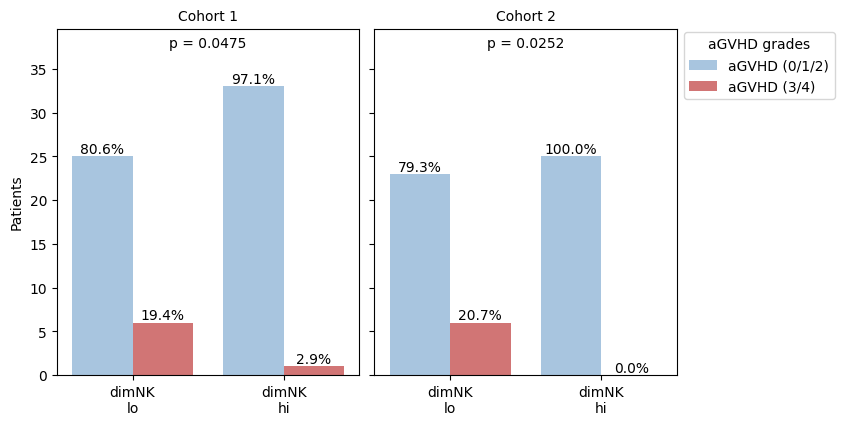

col_0      cGVHD (0)  cGVHD (1)  cGVHD (2)
row_0                                     
dimNK\nlo         16         15         12
dimNK\nhi         30          9          4
Cohort 1
OR / Fisher statistic: 0.000355
p-value: 0.0073
--------
col_0      cGVHD (0)  cGVHD (1)  cGVHD (2)
row_0                                     
dimNK\nlo         17         16          8
dimNK\nhi         23         10          8
Cohort 2
OR / Fisher statistic: 0.0143
p-value: 0.333
--------
0.014280003950645182 0.3327


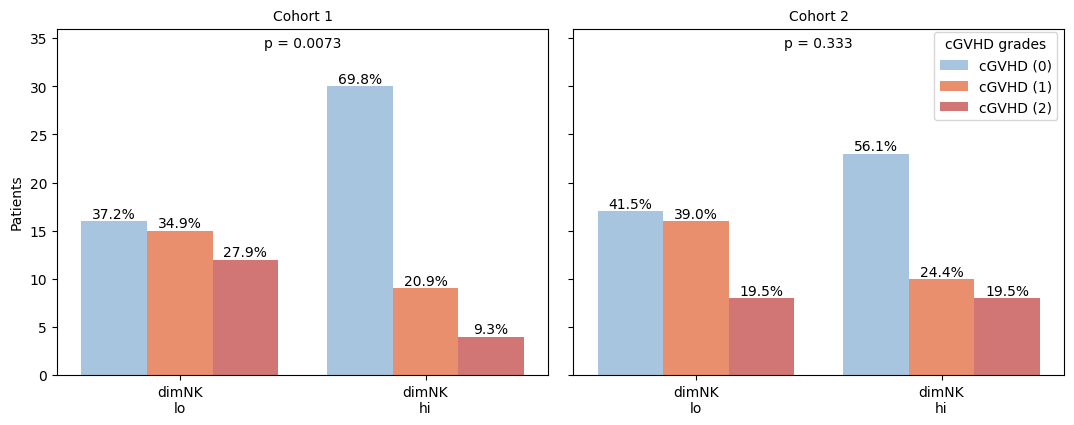

In [13]:
# fisher_plot_builder("CD56dimNK++_tertiles","aGVHD_merged","clinvar_split_score_hue",clin_vars_to_merge=None,scores_to_merge = [3,4])
fisher_plot_builder("CD56dimNK++_tertiles_ONLY_LO_HI","aGVHD_merged","clinvar_split_score_hue",clin_vars_to_merge=None,scores_to_merge = [3,4])
# fisher_plot_builder("CD56dimNK++_tertiles","cGVHD_simple","clinvar_split_score_hue",clin_vars_to_merge=None,scores_to_merge = None)
fisher_plot_builder("CD56dimNK++_tertiles_ONLY_LO_HI","cGVHD_simple","clinvar_split_score_hue",clin_vars_to_merge=None,scores_to_merge = None)
# fisher_plot_builder("CD56dimNK++_tertiles","cGVHD_merged","clinvar_split_score_hue",clin_vars_to_merge=None,scores_to_merge = [1,2])
# fisher_plot_builder("CD56dimNK++_tertiles_ONLY_LO_HI","cGVHD_merged","clinvar_split_score_hue",clin_vars_to_merge=None,scores_to_merge = [1,2])
# fisher_plot_builder("CD56dimNK++_tertiles","cGVHD_merged","clinvar_split_score_hue",clin_vars_to_merge=None,scores_to_merge = [2])
# fisher_plot_builder("CD56dimNK++_tertiles_ONLY_LO_HI","cGVHD_merged","clinvar_split_score_hue",clin_vars_to_merge=None,scores_to_merge = [2])
# fisher_plot_builder("CD56dimNK++_tertiles","no_cGVHD12_no_aGVHD34","clinvar_split_score_hue",clin_vars_to_merge=None,scores_to_merge = None)
# fisher_plot_builder("CD56dimNK++_tertiles_ONLY_LO_HI","no_cGVHD12_no_aGVHD34","clinvar_split_score_hue",clin_vars_to_merge=None,scores_to_merge = None)
# fisher_plot_builder("CD56dimNK++_tertiles","no_cGVHD2_no_aGVHD34","clinvar_split_score_hue",clin_vars_to_merge=None,scores_to_merge = None)
# fisher_plot_builder("CD56dimNK++_tertiles_ONLY_LO_HI","no_cGVHD2_no_aGVHD34","clinvar_split_score_hue",clin_vars_to_merge=None,scores_to_merge = None)
# fisher_plot_builder("cGVHD_grades_adapted","GvLhi_GvHDlo","score_split_clinvar_hue",clin_vars_to_merge=[1,2],scores_to_merge = None)
# fisher_plot_builder("cGVHD_grades_adapted","GvLhi_GvHDlo","score_split_clinvar_hue",clin_vars_to_merge=[2],scores_to_merge = None)
# fisher_plot_builder("aGVHD_grades_adapted","GvLhi_GvHDlo","score_split_clinvar_hue",clin_vars_to_merge=[3,4],scores_to_merge = None)
# fisher_plot_builder("CMV_Status_Recipient(+)","aGVHD_merged","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = [3,4])
# fisher_plot_builder("CMV_Status_Recipient(+)","cGVHD_merged","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = [1,2])
# fisher_plot_builder("CMV_Status_Recipient(+)","cGVHD_merged","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = [2])
# fisher_plot_builder("CMV_Status_Recipient(+)","GvHD_Score_Adapted","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = [0,1])
# fisher_plot_builder("CMV_Status_Recipient(+)","GvHD_Score_Adapted","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = [0])
# fisher_plot_builder("CMV_Status_Recipient(+)","GvL_Score","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = None)
# fisher_plot_builder("CMV_Status_Recipient(+)","GvLhi_GvHDlo","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = None)
# fisher_plot_builder("CMV_Status(R/D)","aGVHD_merged","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = [3,4])
# fisher_plot_builder("CMV_Status(R/D)","cGVHD_merged","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = [1,2])
# fisher_plot_builder("CMV_Status(R/D)","cGVHD_merged","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = [2])
# fisher_plot_builder("CMV_Status(R/D)","GvHD_Score_Adapted","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = [0,1])
# fisher_plot_builder("CMV_Status(R/D)","GvHD_Score_Adapted","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = [0])
# fisher_plot_builder("CMV_Status(R/D)","GvL_Score","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = None)
# fisher_plot_builder("CMV_Status(R/D)","GvLhi_GvHDlo","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = None)
# fisher_plot_builder("MHC_Mismatch_Numeric","GvHD_Score_Adapted","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = [0,1])
# fisher_plot_builder("MHC_Mismatch_Numeric","GvHD_Score_Adapted","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = [0])
# fisher_plot_builder("MHC_Mismatch_Numeric","GvL_Score","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = None)
# fisher_plot_builder("MHC_Mismatch_Numeric","GvLhi_GvHDlo","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = None)
# fisher_plot_builder("ELN_Score","GvLhi_GvHDlo","score_split_clinvar_hue",clin_vars_to_merge=None,scores_to_merge = None)